# Fintech Pulse — Transaction Intelligence Analysis

## Overview
This project analyses 2,512 real banking transactions to uncover 
customer behaviour patterns, identify fraud signals, and generate 
product recommendations for a fintech company.

## Dataset
- Source: Kaggle — Bank Transaction Dataset
- 2,512 transactions, 16 columns
- Covers transaction amounts, channels, customer demographics, 
  login behaviour and account balances

## Key Findings
1. Students (18-30) are the highest spenders per transaction ($316)
2. 77% of all transactions are Debits — consistent with a current account product
3. Branch is the most used channel — suggesting a digitally underserved customer base
4. 122 transactions show suspicious login patterns (3-5 attempts) — potential fraud signal
5. Middle aged customers (31-45) hold the most money but spend the least — untapped opportunity

## Tools Used
- Python, Pandas, Matplotlib
- Jupyter Notebook, VS Code

## Recommendations
- Invest in online channel UX to compete with neobanks
- Flag high login attempt accounts for fraud review
- Target 31-45 segment with investment and savings products
- Build student-focused budgeting and overdraft features

In [2]:
import pandas as pd
print("pandas is ready")

pandas is ready


In [8]:
df = pd.read_csv('../data/bank_transactions_data_2.csv')
print("Data loaded!")
print("Rows:", len(df))

Data loaded!
Rows: 2512


In [9]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

In [11]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


In [13]:

df.groupby ('CustomerOccupation')['TransactionAmount'].mean().sort_values (ascending=False)

CustomerOccupation
Student     313.220746
Retired     294.533673
Doctor      292.700174
Engineer    289.040096
Name: TransactionAmount, dtype: float64

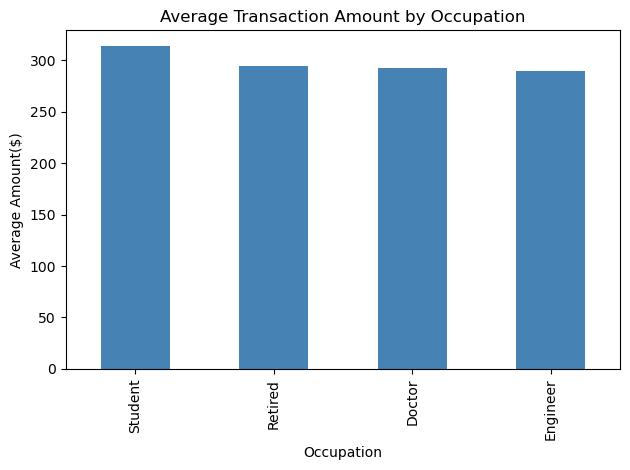

In [16]:
import matplotlib.pyplot as plt

df.groupby('CustomerOccupation')['TransactionAmount'].mean().sort_values(ascending=False).plot(kind='bar',color='steelblue')

plt.title('Average Transaction Amount by Occupation')
plt.xlabel('Occupation')
plt.ylabel('Average Amount($)')
plt.tight_layout()
plt.show()

## Analysis 1: Spending by Occupation

**Question:** Which customer occupation spends the most per transaction?

**Finding:** Students have the highest average transaction amount ($313), 
followed by Retired ($294), Doctor ($292) and Engineer ($289). 
However the difference is small — only $24 separates highest from lowest.

**Insight:** Spending behaviour is relatively consistent across occupations. 
The product team should not over-index on occupation as a segmentation strategy.

In [17]:
df.groupby('TransactionType')['TransactionAmount'].count().sort_values(ascending=False)

TransactionType
Debit     1944
Credit     568
Name: TransactionAmount, dtype: int64

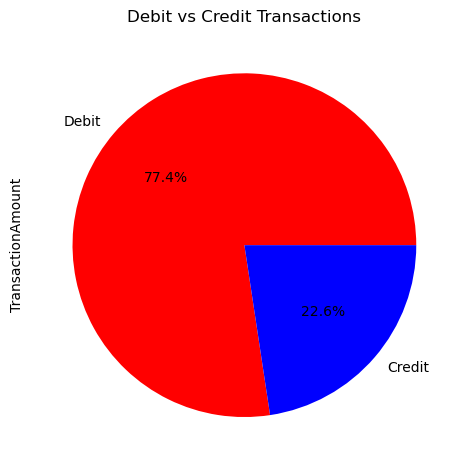

In [21]:
import matplotlib.pyplot as plt
df.groupby('TransactionType')['TransactionAmount'].count().sort_values(ascending=False).plot(kind='pie', colors=['red','blue'],autopct='%1.1f%%')

plt.title('Debit vs Credit Transactions')
plt.tight_layout()
plt.show()


## Analysis 2: Debit vs Credit Transactions

**Question:** What is the split between debit and credit transactions?

**Finding:** 77.4% of all transactions are Debits (1,944) vs only 22.6% 
Credits (568). Debit transactions dominate overwhelmingly.

**Insight:** This is consistent with a current account product where customers 
spend frequently but receive income less often (e.g. monthly salaries). 
The product team should prioritise improving the debit/spending experience 
— faster transaction processing, smarter spending categorisation, and 
real-time spend notifications — as this is where 77% of customer 
activity happens.

In [23]:
df.groupby('Channel')['TransactionAmount'].count().sort_values(ascending=False)

Channel
Branch    868
ATM       833
Online    811
Name: TransactionAmount, dtype: int64

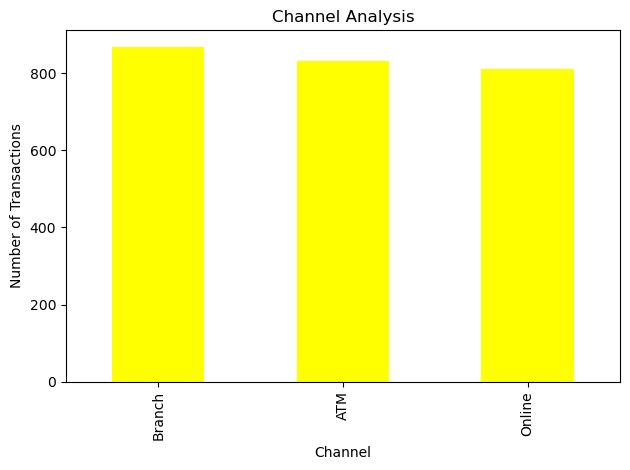

In [26]:
import matplotlib.pyplot as plt

df.groupby('Channel')['TransactionAmount'].count().sort_values(ascending=False).plot(kind='bar',color='yellow')
                                                                                     
plt.title('Channel Analysis')
plt.xlabel('Channel')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

## Analysis 3: Channel Analysis

**Question:** Which channels are most used by customers?

**Finding:** Branch is the most used channel (868 transactions), 
followed closely by ATM (833) and Online (811). 
All three channels are surprisingly close in usage.

**Insight:** The dominance of Branch and ATM suggests an older, 
less digitally engaged customer base — consistent with our earlier 
finding that average customer age is 44. The online channel being 
lowest is a red flag for a modern bank. Competitors like Monzo and 
Revolut are fully digital. This bank risks losing younger customers 
if it doesn't invest in improving its online experience — faster 
interface, better UX, and mobile-first design should be priorities.

In [27]:
df.groupby('LoginAttempts')['TransactionAmount'].count().sort_values(ascending=False)

LoginAttempts
1    2390
4      32
5      32
3      31
2      27
Name: TransactionAmount, dtype: int64

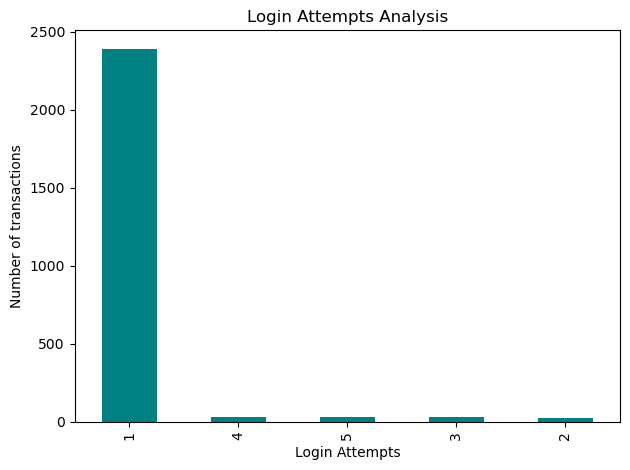

In [29]:
import matplotlib.pyplot as plt

df.groupby('LoginAttempts')['TransactionAmount'].count().sort_values(ascending=False).plot(kind='bar', color='teal')

plt.title('Login Attempts Analysis')
plt.xlabel('Login Attempts')
plt.ylabel('Number of transactions')
plt.tight_layout()
plt.show()

In [30]:
df[df['LoginAttempts'] > 1][['AccountID', 'LoginAttempts']].sort_values('LoginAttempts', ascending=False).head(20)

,AccountID,LoginAttempts
491,AC00318,5
1969,AC00189,5
508,AC00353,5
961,AC00174,5
1884,AC00071,5
953,AC00187,5
2161,AC00139,5
2159,AC00216,5
1213,AC00170,5
463,AC00417,5


In [31]:
df[df['LoginAttempts'] > 1].groupby('AccountID')['LoginAttempts'].max().sort_values(ascending=False).head(10)

AccountID
AC00243    5
AC00011    5
AC00161    5
AC00170    5
AC00174    5
AC00187    5
AC00189    5
AC00216    5
AC00227    5
AC00228    5
Name: LoginAttempts, dtype: int64

## Analysis 4: Login Attempts — Fraud Signal

**Question:** Are there suspicious login patterns that could indicate 
fraud or security risks?

**Finding:** 95% of customers (2,390) log in with a single attempt — 
completely normal behaviour. However 122 transactions show 3-5 login 
attempts. Notably, the distribution across 3, 4 and 5 attempts is 
almost equal (~32 each) which is unusual — forgotten passwords would 
naturally taper off, not stay equal.

**Insight:** Two possible explanations — either older customers are 
struggling with the login interface (UX problem) or these are 
systematic access attempts by bad actors (fraud risk). Either way 
this requires action:
1. Flag accounts with 4-5 attempts for fraud review
2. Investigate whether high attempt accounts correlate with older customers
3. Consider adding a password reset prompt after 2 failed attempts


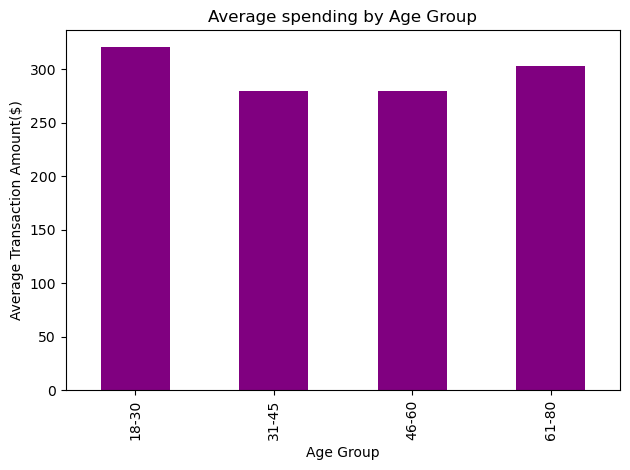

In [33]:
df['AgeGroup']=pd.cut(df['CustomerAge'],bins=[18,30,45,60,80], labels=['18-30','31-45','46-60','61-80'])

df.groupby('AgeGroup')['TransactionAmount'].mean().plot(kind='bar',color='purple')

plt.title('Average spending by Age Group')

plt.xlabel('Age Group')
plt.ylabel('Average Transaction Amount($)')
plt.tight_layout()
plt.show()

## Analysis 5: Average Spending by Age Group

**Question:** Do older customers spend more per transaction 
than younger ones?

**Finding:** The 18-30 age group has the highest average transaction 
amount ($316), followed by 61-80 ($303), then 46-60 ($281) and 
31-45 ($279). This forms a U-shaped spending curve — high at young 
age, dipping in middle age, rising again at retirement.

**Insight:** The original hypothesis that older customers spend more 
was partially correct — 61-80 do spend more than middle aged groups. 
However the youngest customers spend the most overall, likely due to 
large purchases like rent, tuition and lifestyle expenses. 
The product team should prioritise two segments: 18-30 (highest 
spenders, digitally native, likely to adopt new features) and 61-80 
(high value, but may need simpler UX given login attempt patterns 
we identified earlier).

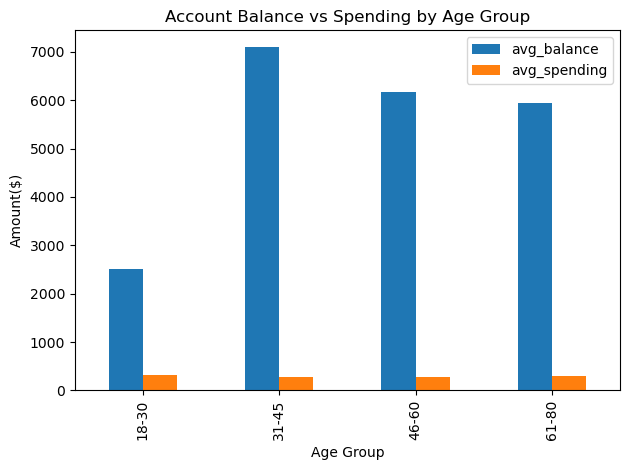

In [36]:
df.groupby('AgeGroup').agg(avg_balance =('AccountBalance','mean'),avg_spending=('TransactionAmount','mean')).round(2).plot(kind='bar')

plt.title('Account Balance vs Spending by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Amount($)')
plt.tight_layout()
plt.show()

## Analysis 6: Account Balance vs Spending by Age Group

**Question:** Are customers spending proportionally to what they 
hold in their accounts?

**Finding:** Across all age groups, average spending is tiny compared 
to average account balance. The 31-45 group holds the highest average 
balance (~$7,000) but has the lowest spending (~$279) — spending only 
4% of their balance per transaction. Even the 18-30 group, who spend 
the most per transaction, only use 12% of their balance.

**Insight:** Customers across all age groups are being highly 
conservative with their money — especially the 31-45 segment who 
hold the most wealth but engage the least. This is a significant 
product opportunity:
1. Target 31-45 customers with investment and savings products
2. Introduce spending insights features to encourage healthy 
   engagement with their balance
3. Consider premium account tiers for high balance customers 
   to increase product stickiness and revenue
   